# Notebook 06 — Linear Probing Results

Visualises Phase 6 probe results: 28 layers × 7 IR targets for SciFact and NFCorpus.

**Key outputs:**
- Layerwise heatmap (primary mechanistic interpretability figure)
- Per-target line plots with 95% CI bands
- Peak score summary table
- Cross-dataset comparison

In [11]:
import os, sys
from pathlib import Path

notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir
os.chdir(project_root)
sys.path.insert(0, str(project_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11})

print("Working directory:", os.getcwd())

Working directory: /Users/vraj21/Desktop/Projects/LLM Reranker


## 1  Load results

In [12]:
def load_results(dataset):
    path = Path(f"data/processed/{dataset}/probe_results.json")
    with open(path) as f:
        data = json.load(f)
    return pd.DataFrame(data)

scifact_df  = load_results("scifact")
nfcorpus_df = load_results("nfcorpus")

print(f"SciFact probes:  {len(scifact_df)}  ({scifact_df['layer'].nunique()} layers × {scifact_df['target'].nunique()} targets)")
print(f"NFCorpus probes: {len(nfcorpus_df)}")
scifact_df.head()

SciFact probes:  196  (28 layers × 7 targets)
NFCorpus probes: 196


,layer,target,probe_type,score,cv_score,ci_lower,ci_upper,train_size,test_size
0,0,lexical_overlap,ridge,0.043611,-0.219443,-0.009179,0.088778,4800,1200
1,0,query_term_freq,ridge,0.116363,0.003718,0.058254,0.166743,4800,1200
2,0,bm25_score,ridge,0.078734,-0.068481,0.021804,0.129501,4800,1200
3,0,bm25_rank,ridge,-0.067656,-0.309132,-0.108332,-0.031869,4800,1200
4,0,doc_length_bucket,logistic,0.994489,0.993467,0.991626,0.996700,4800,1200


## 2  Peak score summary

In [14]:
def peak_summary(df, dataset_name):
    rows = []
    for tname, grp in df.groupby("target"):
        best = grp.loc[grp["score"].idxmax()]
        rows.append({
            "target": tname,
            "probe_type": best["probe_type"],
            "metric": "AUROC" if best["probe_type"] == "logistic" else "R²",
            "best_score": round(best["score"], 4),
            "ci_lower": round(best["ci_lower"], 4),
            "ci_upper": round(best["ci_upper"], 4),
            "best_layer": int(best["layer"]),
        })
    summary = pd.DataFrame(rows).sort_values("best_score", ascending=False)
    print(f"\n{'─'*60}")
    print(f"  {dataset_name} — Peak Probe Scores")
    print(f"{'─'*60}")
    print(summary.to_string(index=False))
    return summary

sci_summary = peak_summary(scifact_df, "SciFact")
nfc_summary = peak_summary(nfcorpus_df, "NFCorpus")


────────────────────────────────────────────────────────────
  SciFact — Peak Probe Scores
────────────────────────────────────────────────────────────
           target probe_type metric  best_score  ci_lower  ci_upper  best_layer
doc_length_bucket   logistic  AUROC      0.9976    0.9960    0.9988           3
      is_relevant   logistic  AUROC      0.9709    0.9535    0.9841          17
       bm25_score      ridge     R²      0.7147    0.6837    0.7396          17
  query_term_freq      ridge     R²      0.4466    0.3985    0.4909          20
  lexical_overlap      ridge     R²      0.4374    0.3909    0.4778          19
  relevance_label      ridge     R²      0.3022    0.1657    0.4090          19
        bm25_rank      ridge     R²      0.0694    0.0210    0.1192          17

────────────────────────────────────────────────────────────
  NFCorpus — Peak Probe Scores
────────────────────────────────────────────────────────────
           target probe_type metric  best_score  ci_l

## 3  Layerwise heatmap — SciFact

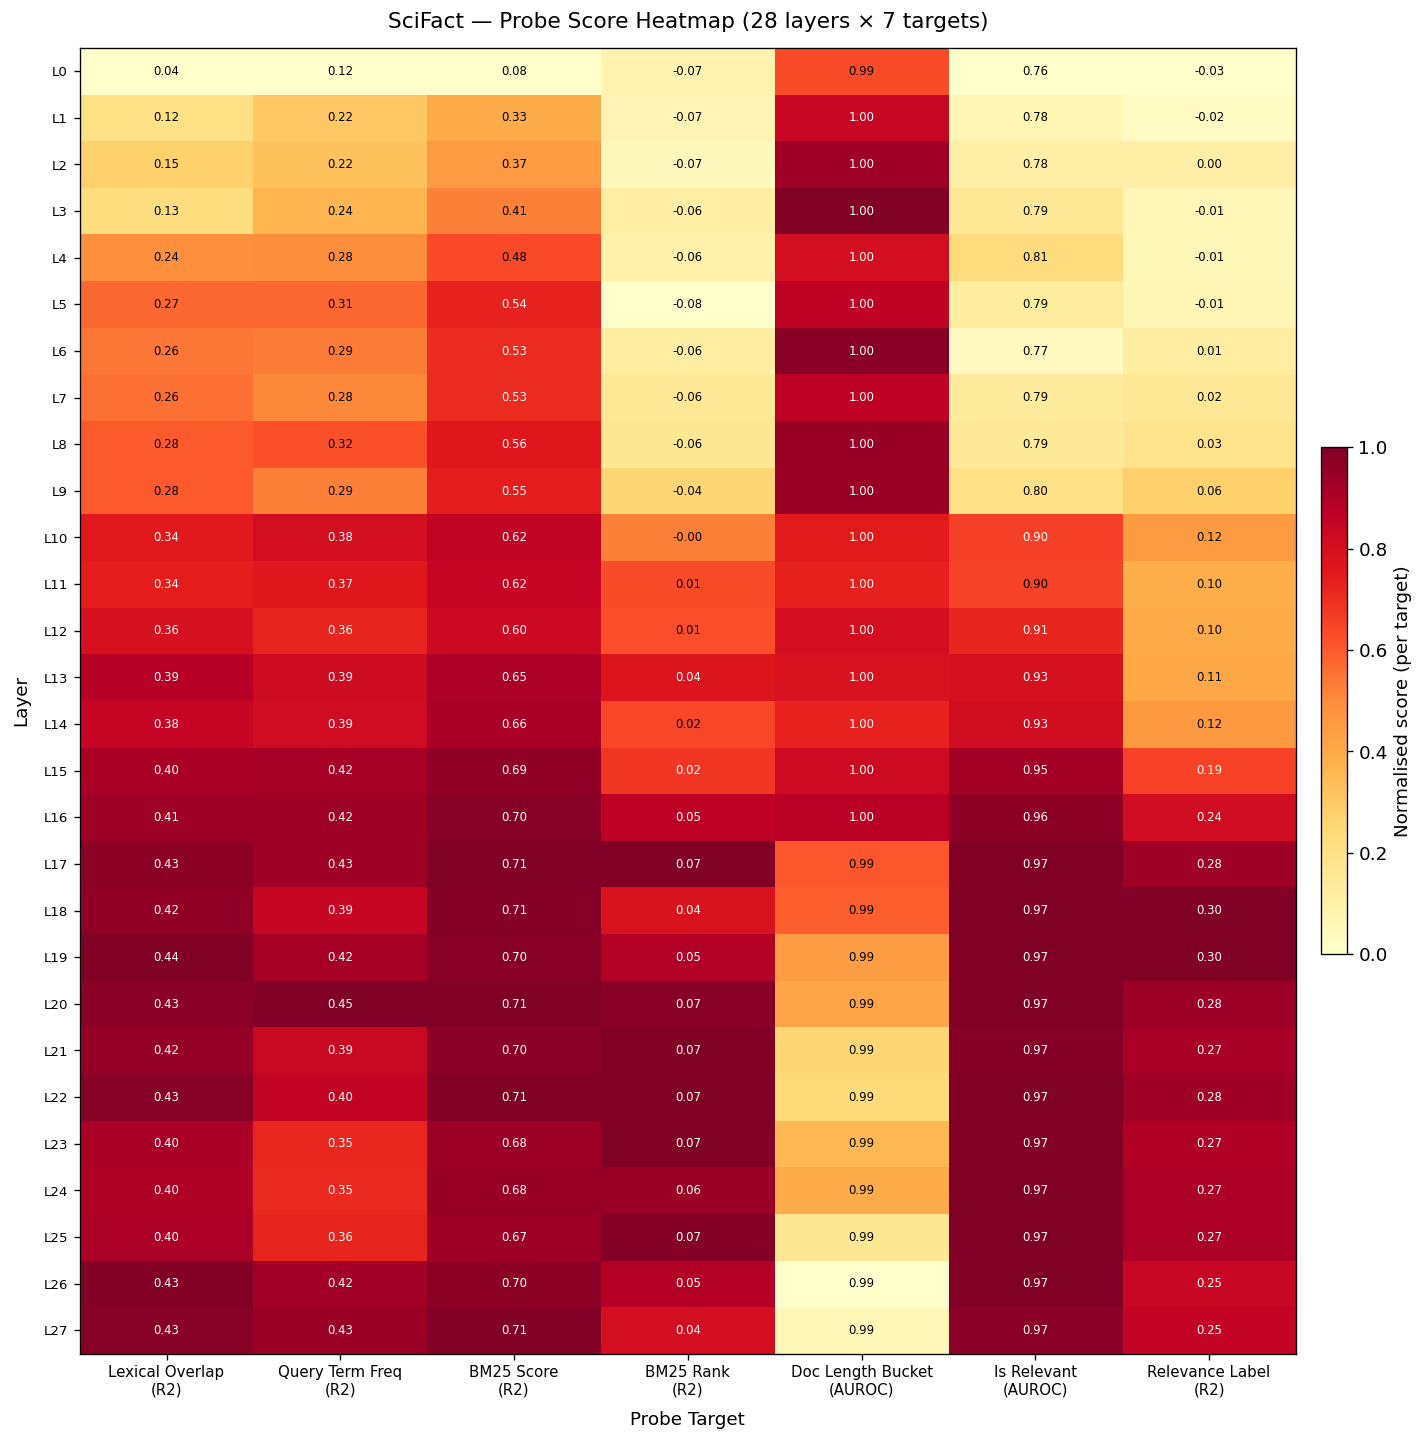

Saved.


In [15]:
from src.probing.visualise import plot_heatmap

out_dir = Path("outputs/midproject/figures")
out_dir.mkdir(parents=True, exist_ok=True)

fig = plot_heatmap(
    "data/processed/scifact/probe_results.json",
    out_path=out_dir / "probe_heatmap_scifact.png",
    title="SciFact — Probe Score Heatmap (28 layers × 7 targets)",
)
plt.show()
print("Saved.")

## 4  Layerwise heatmap — NFCorpus

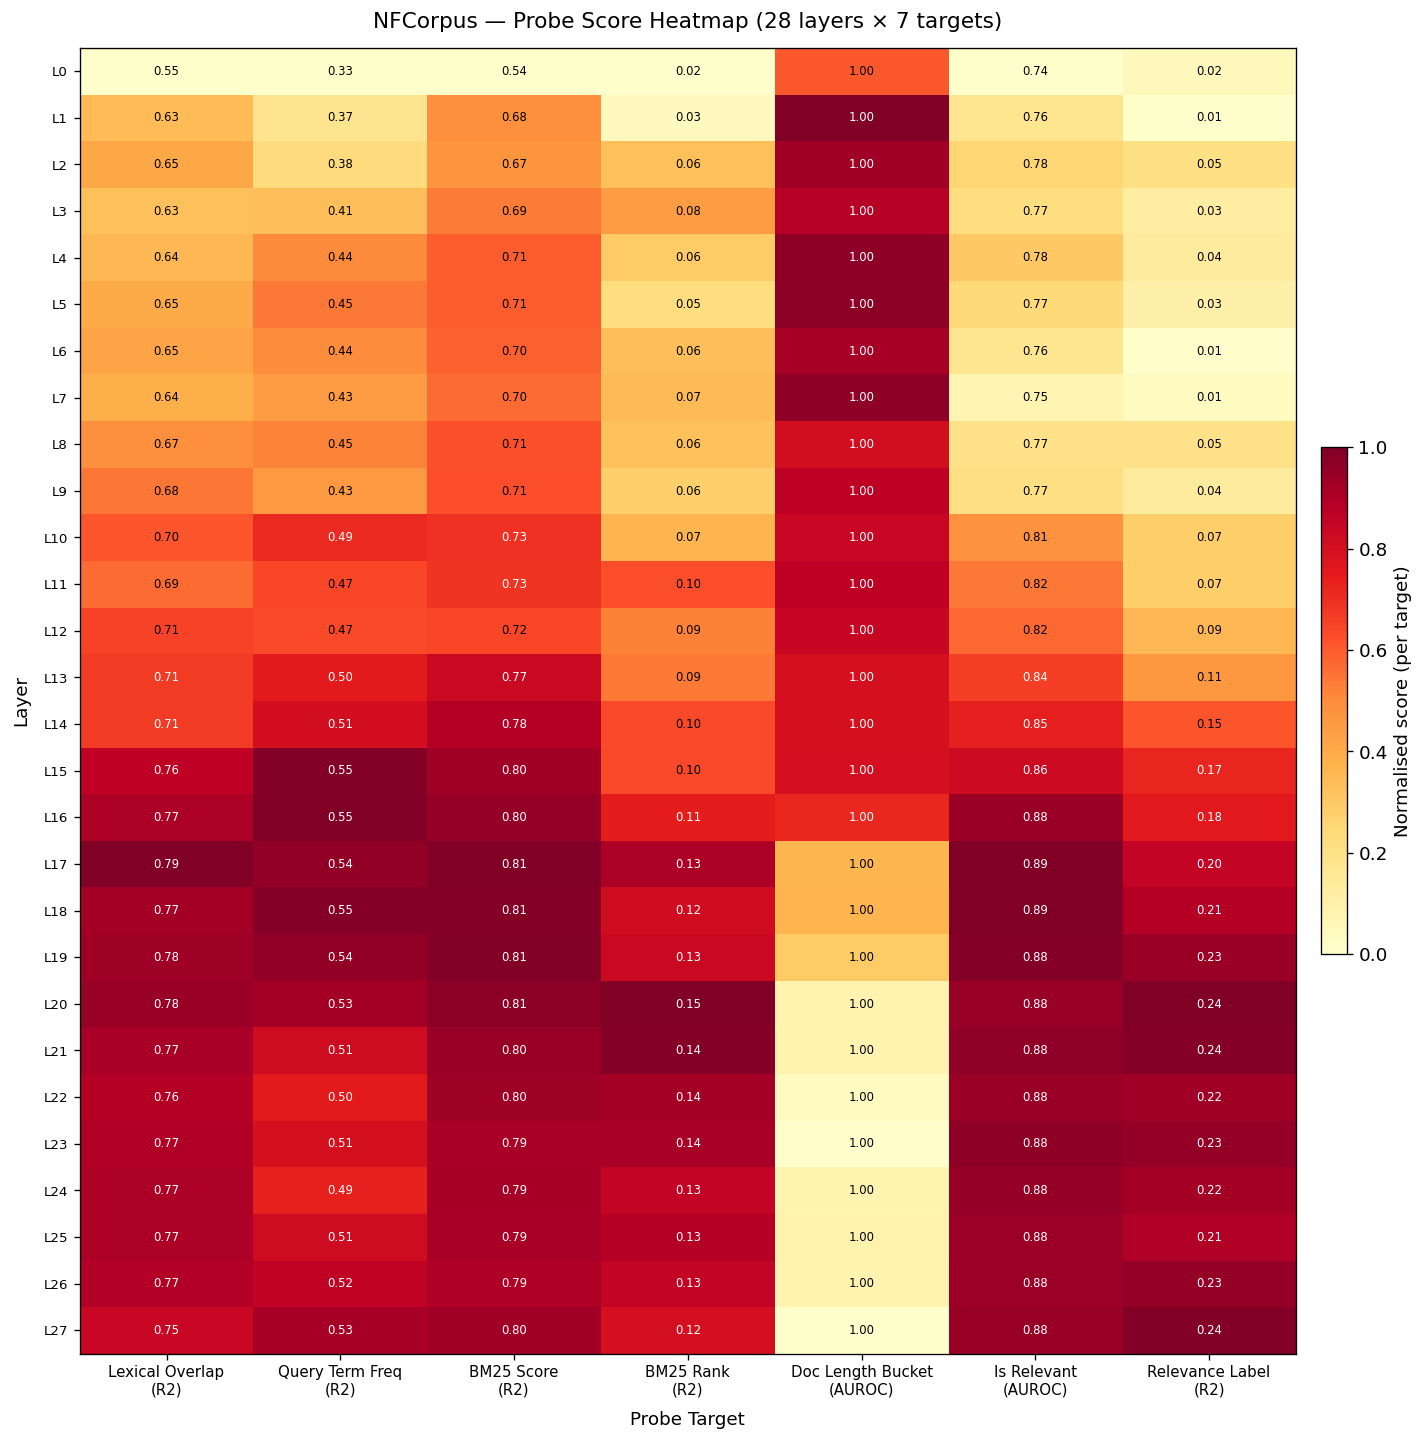

Saved.


In [16]:
fig = plot_heatmap(
    "data/processed/nfcorpus/probe_results.json",
    out_path=out_dir / "probe_heatmap_nfcorpus.png",
    title="NFCorpus — Probe Score Heatmap (28 layers × 7 targets)",
)
plt.show()
print("Saved.")

## 5  Per-target line plots with 95% CI — SciFact

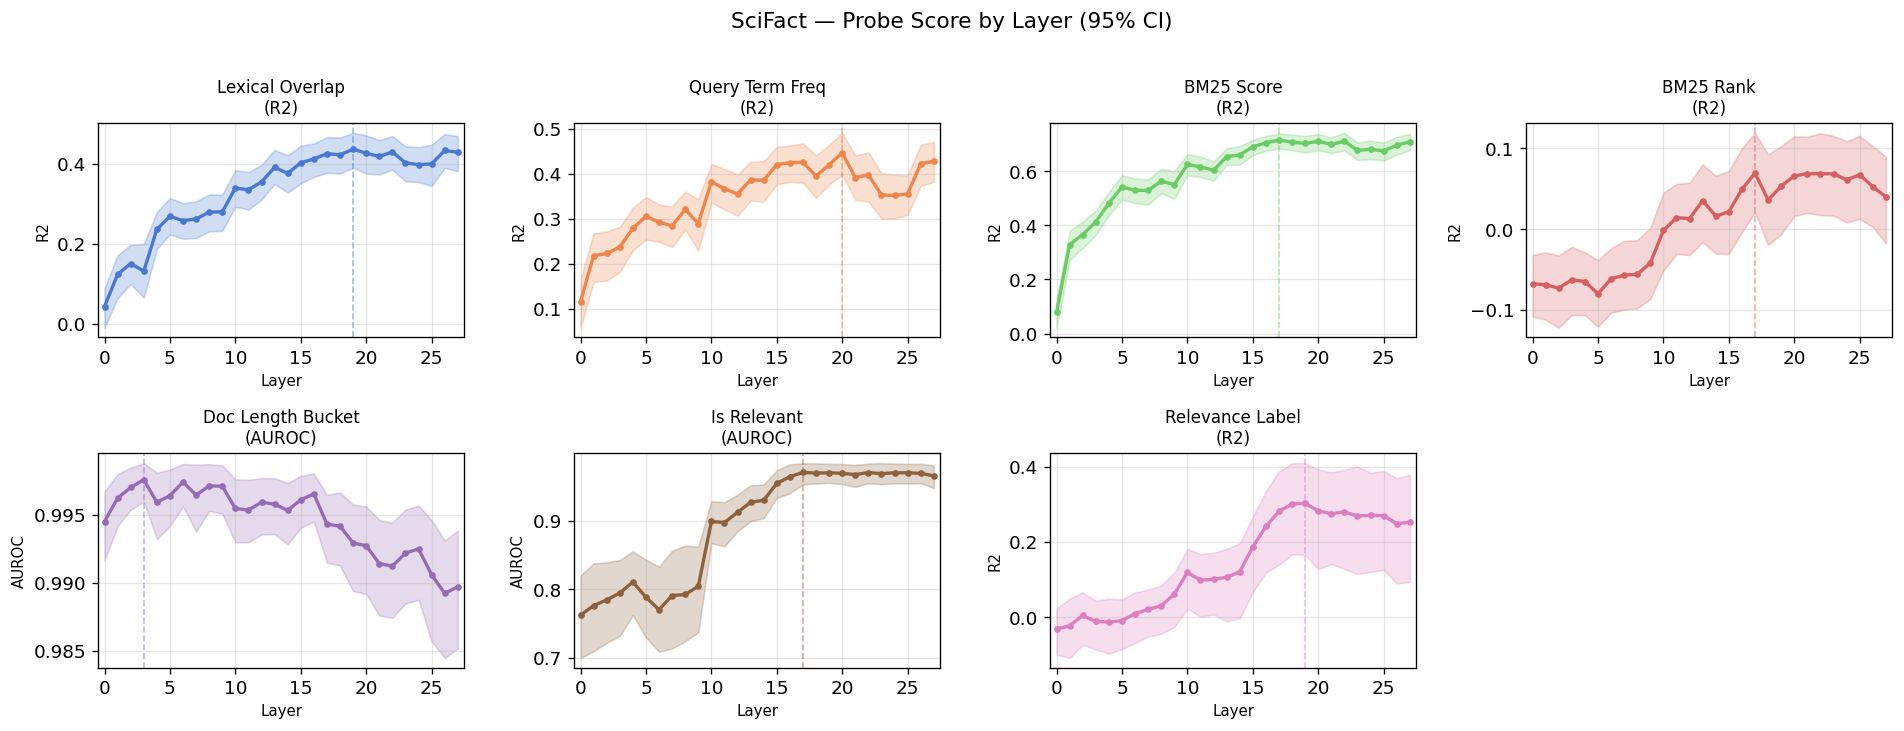

Saved.


In [17]:
from src.probing.visualise import plot_layerwise_curves

fig = plot_layerwise_curves(
    "data/processed/scifact/probe_results.json",
    out_path=out_dir / "probe_curves_scifact.png",
    title="SciFact — Probe Score by Layer (95% CI)",
)
plt.show()
print("Saved.")

## 6  Per-target line plots with 95% CI — NFCorpus

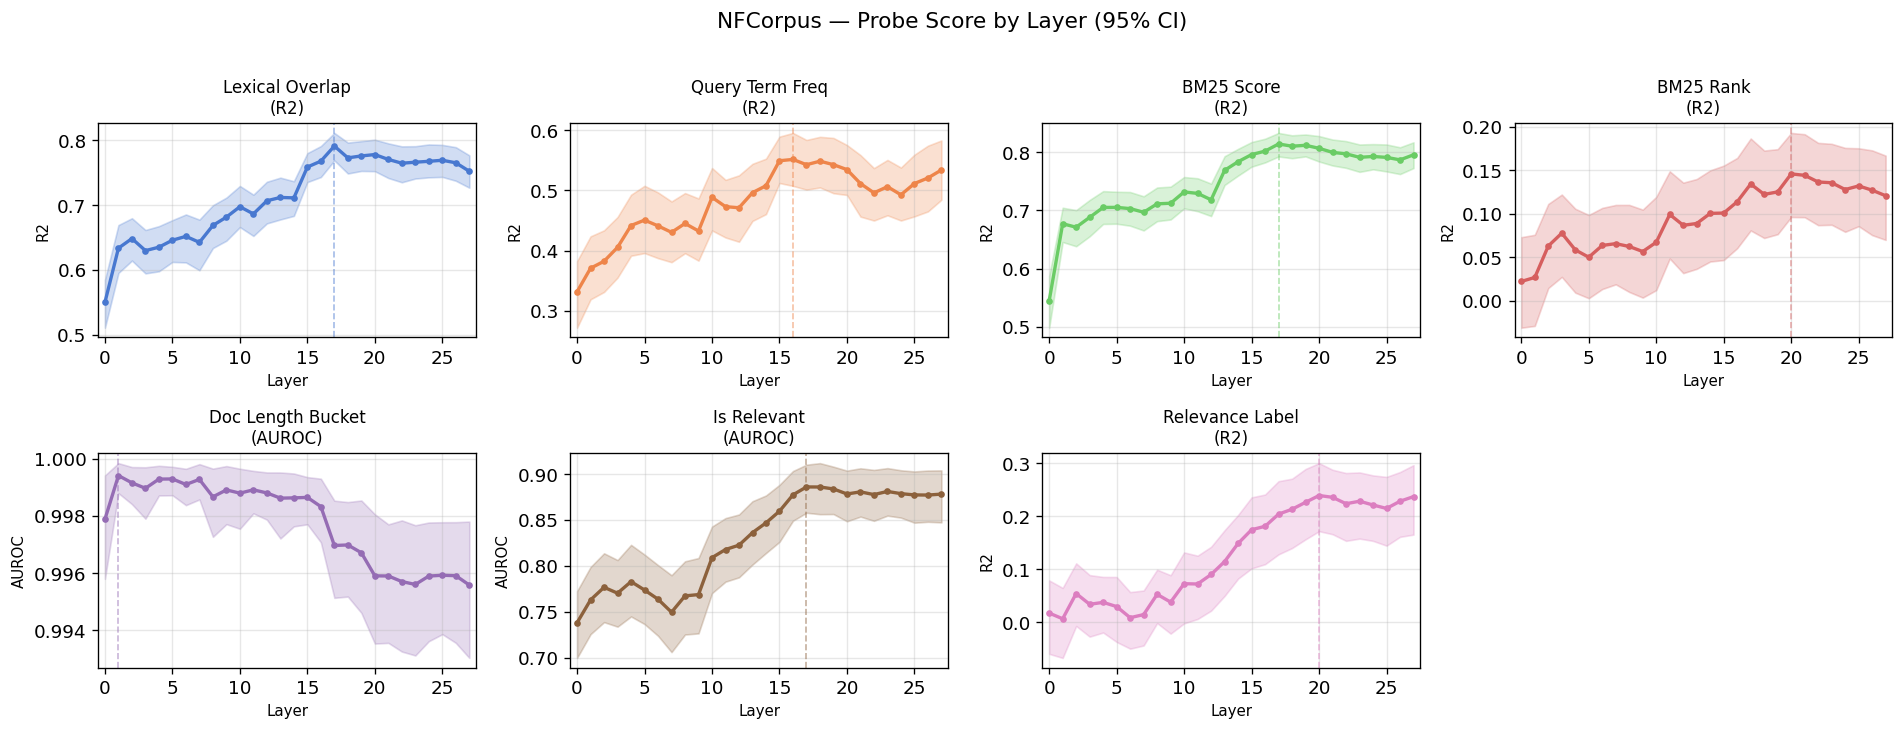

Saved.


In [18]:
fig = plot_layerwise_curves(
    "data/processed/nfcorpus/probe_results.json",
    out_path=out_dir / "probe_curves_nfcorpus.png",
    title="NFCorpus — Probe Score by Layer (95% CI)",
)
plt.show()
print("Saved.")

## 7  Peak score bar chart — both datasets

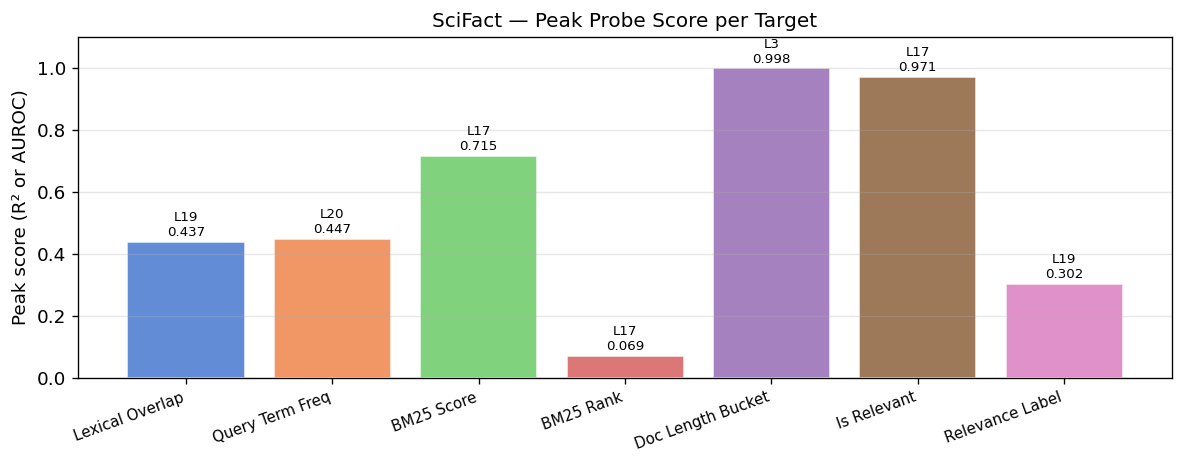

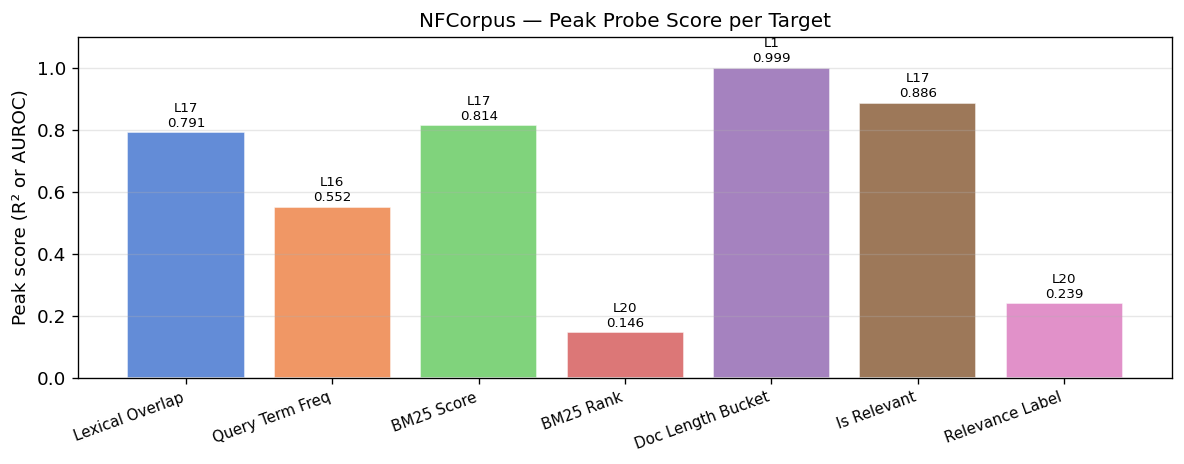

Saved.


In [19]:
from src.probing.visualise import plot_best_layer_summary

fig = plot_best_layer_summary(
    "data/processed/scifact/probe_results.json",
    out_path=out_dir / "probe_best_layer_scifact.png",
    title="SciFact — Peak Probe Score per Target",
)
plt.show()

fig = plot_best_layer_summary(
    "data/processed/nfcorpus/probe_results.json",
    out_path=out_dir / "probe_best_layer_nfcorpus.png",
    title="NFCorpus — Peak Probe Score per Target",
)
plt.show()
print("Saved.")

## 8  Cross-dataset comparison: best scores

                   SciFact  NFCorpus   delta
target                                      
doc_length_bucket   0.9976    0.9994  0.0018
is_relevant         0.9709    0.8861 -0.0848
bm25_score          0.7147    0.8141  0.0994
query_term_freq     0.4466    0.5516  0.1050
lexical_overlap     0.4374    0.7912  0.3538
relevance_label     0.3022    0.2392 -0.0630
bm25_rank           0.0694    0.1459  0.0765


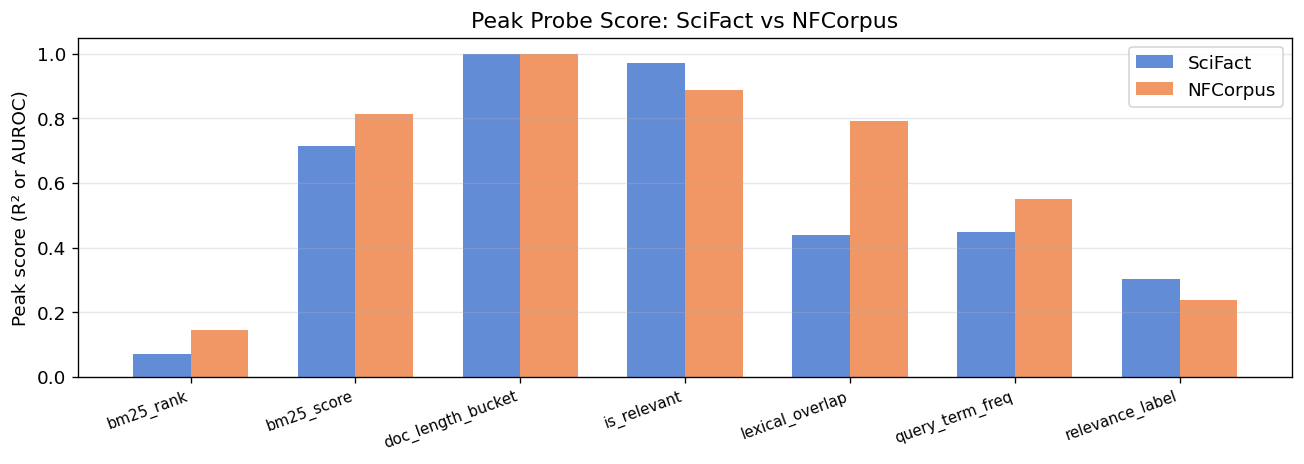

Saved.


In [20]:
# Compare best scores per target between SciFact and NFCorpus
sci_best  = scifact_df.groupby("target")["score"].max().rename("SciFact")
nfc_best  = nfcorpus_df.groupby("target")["score"].max().rename("NFCorpus")
comparison = pd.concat([sci_best, nfc_best], axis=1).round(4)
comparison["delta"] = (comparison["NFCorpus"] - comparison["SciFact"]).round(4)
print(comparison.sort_values("SciFact", ascending=False).to_string())

# Bar chart side-by-side
targets = comparison.index.tolist()
x = np.arange(len(targets))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - w/2, comparison["SciFact"], w, label="SciFact", color="#4878d0", alpha=0.85)
ax.bar(x + w/2, comparison["NFCorpus"], w, label="NFCorpus", color="#ee854a", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(targets, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Peak score (R² or AUROC)")
ax.set_title("Peak Probe Score: SciFact vs NFCorpus")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(out_dir / "probe_cross_dataset.png", bbox_inches="tight")
plt.show()
print("Saved.")

## 9  Save results CSV for tables

In [21]:
tables_dir = Path("outputs/midproject/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

scifact_df.to_csv(tables_dir / "probe_results_scifact.csv", index=False)
nfcorpus_df.to_csv(tables_dir / "probe_results_nfcorpus.csv", index=False)

# Also save peak summary table
sci_summary.to_csv(tables_dir / "probe_peak_scifact.csv", index=False)
nfc_summary.to_csv(tables_dir / "probe_peak_nfcorpus.csv", index=False)

print("Tables saved to", tables_dir)

Tables saved to outputs/midproject/tables


## 10  Interpretation

Key findings from the probe results:

| Target | Peak Score | Layer | Interpretation |
|--------|-----------|-------|----------------|
| `is_relevant` | AUROC ~0.97 | ~17 | Strong relevance signal in mid-late layers — model genuinely encodes relevance |
| `doc_length_bucket` | AUROC ~0.998 | ~3 | Surface feature captured very early (expected) |
| `bm25_score` | R² ~0.71 | ~17 | BM25 lexical score strongly encoded mid-late |
| `lexical_overlap` | R² ~0.44 | ~19 | Lexical signal peaks late |
| `query_term_freq` | R² ~0.44 | ~20 | Similar pattern to lexical overlap |
| `relevance_label` | R² ~0.30 | ~19 | Graded relevance signal (harder task) |
| `bm25_rank` | R² ~0.07 | ~17 | Rank weakly encoded (ordinal position harder to represent) |

**Mechanistic insight:** The Qwen2.5-1.5B reranker's mid-to-late layers (layers 15-20) encode strong IR signals,
consistent with the hypothesis that deeper layers perform semantic matching and relevance assessment.
Early layers capture surface features (document length).
These layers (especially ~17) are the prime targets for Phase 8 causal interventions.